# Logistic Regression on Win Column

This notebook will build and train a logistic regression model to classify each match into win/loss. We will do this on three versions of our dataset. One will be trained on the usual dataset, one on just the odds, and one on the dataset without odds. The reason we will do this is to investigate the effect that the odds columns have on prediction. Since these are win probabilities given by bookmakers, they are a very good prediction of who will win the match. They already include much of the information given by the other columns in the dataset, since this is publicly available information and bookmaker models would have taken exactly this information into account when producing the odds. Hence, it may be the case that odds are extremely good predictor of win/loss, and all other columns are redundant. On the other hand, it may be the case that the other columns are able to give a good prediction of the gap between the true win probability and the bookmaker-predicted win probability. This is what we will explore with the different datasets.

## 1. Preparing the Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from utils import shuffle_data_df, train_test_split_df, standardise

sns.set_style("whitegrid")

df = pd.read_csv("../Data/c_w_data.csv")
df = df.copy().drop(columns=['Score'])


df.head()

,Series,Surface,Round,dj_pts,dj_rank,dj_odds,opp_pts,opp_rank,opp_odds,dj_win,age,is_outdoor,is_five_sets,5SMA
0,International,Clay,2nd Round,417,97,5.00,1170,28,1.14,0,18,1,0,1.000000
1,Masters,Hard,1st Round,440,97,3.50,1385,18,1.28,0,18,1,0,0.500000
2,Grand Slam,Hard,1st Round,431,97,2.50,825,43,1.50,1,18,1,1,0.333333
3,Grand Slam,Hard,2nd Round,431,97,3.50,1230,24,1.28,1,18,1,1,0.500000
4,Grand Slam,Hard,3rd Round,431,97,2.75,770,48,1.39,0,18,1,1,0.600000


In [2]:
# Shuffle data
df_shuff = shuffle_data_df(df)
df_shuff.head()

,Series,Surface,Round,dj_pts,dj_rank,dj_odds,opp_pts,opp_rank,opp_odds,dj_win,age,is_outdoor,is_five_sets,5SMA
1057,Masters 1000,Clay,The Final,8260,1,1.440,5750,5,2.75,1,35,1,0,0.8
938,Grand Slam,Grass,The Final,12415,1,1.550,6620,3,2.60,1,32,1,1,1.0
1228,ATP250,Hard,Quarterfinals,4580,5,1.170,1120,47,5.00,1,38,0,0,0.8
683,Grand Slam,Clay,1st Round,13845,1,1.002,603,87,34.00,1,28,1,1,1.0
282,ATP500,Hard,The Final,7330,4,1.360,2195,15,3.20,1,22,1,0,0.8


In [3]:
# Train test split
df_train, df_test = train_test_split_df(df_shuff, 0.8)

## 2. Logistic Regression Model / Functions

In [4]:
def stable_sigmoid(x):
    

    return np.where(x >= 0, 1. / ( 1. + np.exp(-x)), np.exp(x) / ( 1. + np.exp(x) ))

In [5]:
def binary_cross_entrop(y_true, probs, eps=1e-7):

    """
        Computes the binary cross entrop given a vector of true binary labels and a vector of
        probability predictions
    """

    probs = np.clip(probs, eps, 1-eps)
    return - np.mean(y_true * np.log(probs) + (1 - y_true) * (np.log(1 - probs)))

In [6]:
def bce_grad(X, y_true, probs):

    """
        Computes the gradient of the binary cross-entropy with respect to theta.
    """

    return (1 / X.shape[0]) * X.T @ (probs - y_true)

In [7]:
def gradient_descent(X, y, lr=1e-3, iter=10000, thresh=1e-7):

    """
        This is a gradient descent training loop for logistic regression.
    """

    # Initialise coefficients, probabilities vector and loss array
    theta = np.ones((X.shape[1], 1))
    losses = []

    # Begin descent loop
    for i in range(iter):

        # Calculate probabilities
        z = (X @ theta).reshape(-1, 1)
        probs = stable_sigmoid(z)

        # Calculate binary cross entropy and gradient
        loss = binary_cross_entrop(y, probs)
        losses.append(float(loss))
        grad = bce_grad(X, y, probs)

        # Print loss every 200th iteration number
        if (i+1) % 200 == 0:
            print(f"Iteration {i+1}")
            print("Loss", loss)

        # Update theta
        theta_new = theta - lr * grad

        # Check for early convergence
        if np.linalg.norm(grad) <= thresh:
            print(fr"We have reached early convergence on iteration {i+1}.")
            return theta_new

        # Update theta
        theta = theta_new

    print(fr"Reached max iterations.")
    return theta, losses

In [8]:
def hard_thresh(probs):

    """
        Calculate the 1/0 prediction from the probability scores
    """

    return np.where(probs >= 0.5, 1, 0)

In [9]:
def accuracy(y_true, y_hat):

    """
        Calculates the accuracy of the model. y_true are the true labels and y_hat are the hard
        thresholded probabilities.
    """

    return np.mean(y_true == y_hat) * 100

## 3. Odds Dataset

We begin with a dataset containing only the odds columns, and evaluate how well it predicts Djokovic's win probability. First let us prepare the data for this specific task.

In [10]:
# Forming dataset
df_odds_train = df_train.copy()[['dj_odds', 'opp_odds', 'dj_win']]
df_odds_test = df_test.copy()[['dj_odds', 'opp_odds', 'dj_win']]

In [11]:
df_odds_train.head()

,dj_odds,opp_odds,dj_win
1057,1.440,2.75,1
938,1.550,2.60,1
1228,1.170,5.00,1
683,1.002,34.00,1
282,1.360,3.20,1


In [12]:
# Separating target from predictors
y_train, y_test = df_odds_train['dj_win'].to_numpy().reshape(-1, 1), df_odds_test['dj_win'].to_numpy().reshape(-1, 1)
X_train, X_test = df_odds_train[['dj_odds', 'opp_odds']].to_numpy(), df_odds_test[['dj_odds', 'opp_odds']].to_numpy()

In [13]:
# Standardise and augment prediction matrix
X_train_std = standardise(X_train)
X_test_std = standardise(X_test, X_train)

X_train_sa = np.concatenate([np.ones((X_train_std.shape[0], 1)), X_train_std], axis=1)
X_test_sa = np.concatenate([np.ones((X_test_std.shape[0], 1)), X_test_std], axis=1)

Now that our data is fully separated, standardised, and augmented, we can train our model.

In [14]:
# Train the model
theta, losses = gradient_descent(X_train_sa, y_train, iter=300000)

Iteration 200
Loss 0.5625028181753648
Iteration 400
Loss 0.5535272264329986
Iteration 600
Loss 0.5450122507094165
Iteration 800
Loss 0.5369213019611656
Iteration 1000
Loss 0.529221389449293
Iteration 1200
Loss 0.5218827749372907
Iteration 1400
Loss 0.5148786592320563
Iteration 1600
Loss 0.5081848988417484
Iteration 1800
Loss 0.5017797504404817
Iteration 2000
Loss 0.4956436408348532
Iteration 2200
Loss 0.4897589601943584
Iteration 2400
Loss 0.48410987641588565
Iteration 2600
Loss 0.4786821686260141
Iteration 2800
Loss 0.47346307797171405
Iteration 3000
Loss 0.46844117400114627
Iteration 3200
Loss 0.463606235084103
Iteration 3400
Loss 0.4589491414599078
Iteration 3600
Loss 0.4544617796231722
Iteration 3800
Loss 0.45013695685824073
Iteration 4000
Loss 0.4459683248041214
Iteration 4200
Loss 0.4419503109646827
Iteration 4400
Loss 0.43807805706430825
Iteration 4600
Loss 0.4343473630768781
Iteration 4800
Loss 0.43075463561693567
Iteration 5000
Loss 0.42729683917123645
Iteration 5200
Loss 0.42

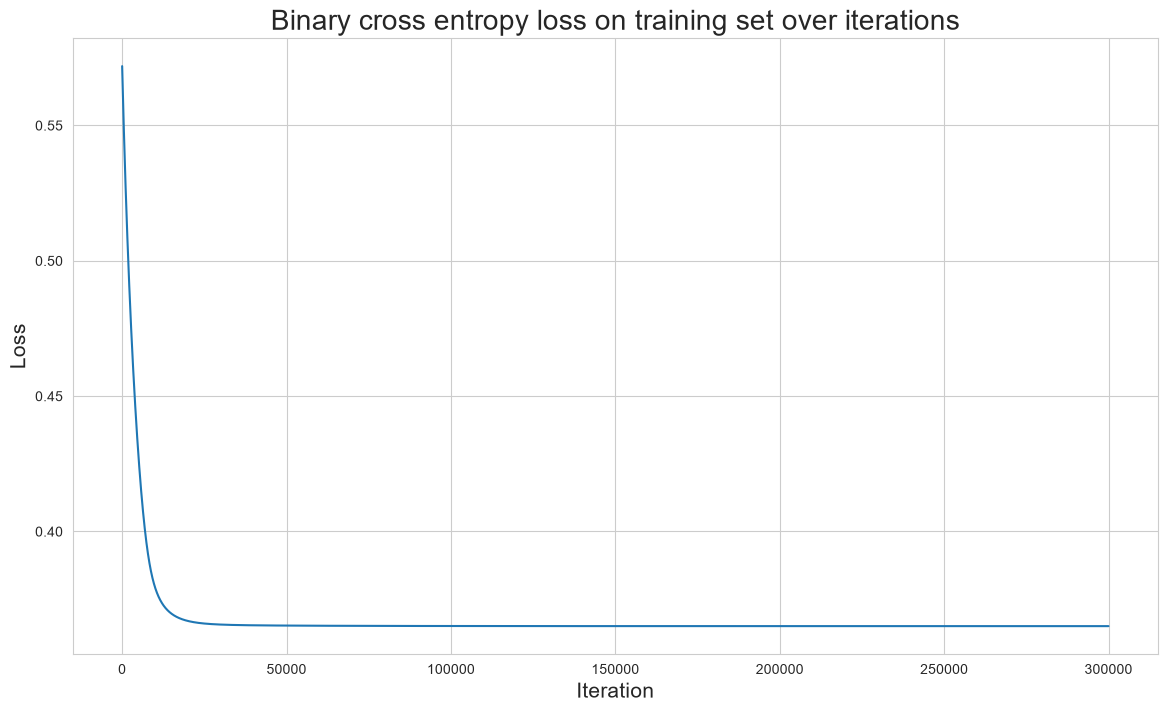

In [15]:
# Plotting the training binary cross entropy (loss) curve
plt.figure(figsize=(14, 8))
plt.plot(losses)
plt.xlabel("Iteration", fontsize=15)
plt.ylabel("Loss", fontsize=15)
plt.title("Binary cross entropy loss on training set over iterations", fontsize=20)
plt.show()


In [16]:
# Test set loss and accuracy
z_test = X_test_sa @ theta
probs_test = stable_sigmoid(z_test)
bce = binary_cross_entrop(y_test, probs_test)
y_hat = hard_thresh(probs_test)
acc = accuracy(y_test, y_hat)
print("Odds Logistic Regression Test Loss and Accuracy")
print("-"*50)
print(f"Test Loss: {bce:.2f}")
print(f"Accuracy: {acc}%")

Odds Logistic Regression Test Loss and Accuracy
--------------------------------------------------
Test Loss: 0.36
Accuracy: 84.0%


In [17]:
majority_baseline = df['dj_win'].mean()   # accuracy of "always predict the majority class"
print(majority_baseline)

0.8398718975180144


## 4. No Odds Dataset

We will now train a logistic regression model on the same train / test split of the dataset using all columns apart from the odds columns. This will be informative to see whether the bookmaker predictions will be better indicators of win/loss than what we can predict using our chosen variables.

In [18]:
# Forming dataset
df_nodds_train = df_train.copy().drop(columns=['dj_odds', 'opp_odds'])
df_nodds_test = df_test.copy().drop(columns=['dj_odds', 'opp_odds'])

In [19]:
df_nodds_train.head()

,Series,Surface,Round,dj_pts,dj_rank,opp_pts,opp_rank,dj_win,age,is_outdoor,is_five_sets,5SMA
1057,Masters 1000,Clay,The Final,8260,1,5750,5,1,35,1,0,0.8
938,Grand Slam,Grass,The Final,12415,1,6620,3,1,32,1,1,1.0
1228,ATP250,Hard,Quarterfinals,4580,5,1120,47,1,38,0,0,0.8
683,Grand Slam,Clay,1st Round,13845,1,603,87,1,28,1,1,1.0
282,ATP500,Hard,The Final,7330,4,2195,15,1,22,1,0,0.8


We also need to one-hot encode the categorical features since our model requires numerical feature columns.

In [20]:
# Form one-hot data
series = pd.get_dummies(df_nodds_train['Series'])
surface = pd.get_dummies(df_nodds_train['Surface'])
round = pd.get_dummies(df_nodds_train['Round'])
one_hots_train = pd.concat([series, surface, round], axis=1).astype(int)
one_hots_train.head()

,ATP250,ATP500,Grand Slam,International,International Gold,Masters,Masters 1000,Masters Cup,Carpet,Clay,Grass,Hard,1st Round,2nd Round,3rd Round,4th Round,Quarterfinals,Round Robin,Semifinals,The Final
1057,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,1
938,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1
1228,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0
683,0,0,1,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0
282,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1


In [21]:
# Same for test set
series = pd.get_dummies(df_nodds_test['Series'])
surface = pd.get_dummies(df_nodds_test['Surface'])
round = pd.get_dummies(df_nodds_test['Round'])
one_hots_test = pd.concat([series, surface, round], axis=1).astype(int)

In [22]:
# Drop old columns
df_nodds_train = df_nodds_train.copy().drop(columns=['Series', 'Surface', 'Round'])
df_nodds_test = df_nodds_test.copy().drop(columns=['Series', 'Surface', 'Round'])

In [23]:
# Separate target from predictors
y_train, y_test = df_nodds_train['dj_win'].to_numpy(), df_nodds_test['dj_win'].to_numpy()
X_train, X_test = df_nodds_train.drop(columns='dj_win'), df_nodds_test.drop(columns='dj_win')

In [24]:
# Now convert to numpy arrays, standardise, and concatenate with dummy columns (dont want to standardise
# one hot encoded columns)
X_nodds_train_std = standardise(X_train.to_numpy())
X_nodds_test_std = standardise(X_test.to_numpy(), scaler=X_train.to_numpy())

X_nodds_train_final = np.concatenate([np.ones((X_nodds_train_std.shape[0], 1)), 
                                    X_nodds_train_std, one_hots_train.to_numpy()], axis=1)
X_nodds_test_final = np.concatenate([np.ones((X_nodds_test_std.shape[0], 1)), 
                                    X_nodds_test_std, one_hots_test.to_numpy()],axis=1)

Now our data is fully prepared for us to run our logistic regression.

In [ ]:
theta_nodds, losses_nodds = gradient_descent(X_nodds_train_final, y_train)